# 🔍 Scratch / Contam / Other — Defect Detection Pipeline

---

## What does this notebook do?

Imagine you have a camera taking pictures of parts coming off a factory line.  
Some parts are **dirty** (contamination), some have **scratches**, and some have **other weird marks**.  
You want a computer to look at a new photo and say *"hey, that part has a scratch right here!"*  

This notebook teaches a computer to do exactly that — step by step.

---

## The 4 steps

| Step | What happens |
|------|--------------|
| **1. Prepare** | Organise your labeled photos into folders the AI can read |
| **2. Verify** | Double-check every photo has a matching label file |
| **3. Train** | The AI looks at all the labeled photos and learns what defects look like |
| **4. Predict** | Point the AI at new photos — it draws colored masks on any defects it finds |

Run the cells top-to-bottom, in order.

---
## Cell 1 — Imports & Setup

Think of **imports** like opening your toolbox before you start work.  
We grab tools for:
- **pathlib** → working with file paths (finding folders, making folders)
- **shutil** → copying and moving files
- **random** → shuffling the photos so train/val split is random
- **yaml** → reading the `config.yaml` settings file
- **ultralytics** → the YOLOv8 AI library that does the actual detection

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False
No GPU


In [2]:
import shutil
import random
import yaml
from pathlib import Path

# __file__ doesn't exist in a notebook, so we anchor to the notebook's folder instead
SCRIPT_DIR = Path().resolve()

print(f"Working directory: {SCRIPT_DIR}")
print("All tools loaded successfully!")

Working directory: C:\Users\7364250\ML_pipeline
All tools loaded successfully!


---
## Cell 2 — Load the Config File

Instead of burying numbers inside the code, all the settings live in **`config.yaml`**.

Think of it like the settings menu on a video game — you change things there without touching the engine.

Key settings:
- **`labels_dir`** — the folder that holds your photos + label files
- **`labels_version`** — the default labeling round (a subfolder of `labels_dir`, e.g. `c_0702`). Cell 3 shows every available version and asks — press **Enter** to accept this default, or type another name to switch.
- **`classes`** — what class number means what name (0=comtam_dust, 1=comtam_stain, ... see config.yaml)
- **`train_ratio` / `val_ratio`** — how the photos are divided (0.70/0.15 = 70% train, 15% val, 15% test)
- **`epochs`** — how many times the AI reads through all the training photos
- **`batch_size`** — how many photos the AI looks at at once before updating itself
- **`patience`** — if the AI isn't getting better for this many epochs, stop early

In [3]:
def load_config(path="config.yaml"):
    with open(SCRIPT_DIR / path, encoding="utf-8") as f:
        return yaml.safe_load(f)

def resolve(rel):
    """Turn a relative path string into a full absolute path."""
    return SCRIPT_DIR / rel

cfg = load_config()

tr = cfg["data"]["train_ratio"]
vr = cfg["data"].get("val_ratio", 0.15)

print("=== Config loaded ===")
print(f"Labels folder : {cfg['data']['labels_dir']}/{cfg['data']['labels_version']}")
print(f"Classes       : {dict(cfg['data']['classes'])}")
print(f"Split         : {tr:.0%} train / {vr:.0%} val / {1 - tr - vr:.0%} test")
print(f"Keep backgrounds: {cfg['data'].get('keep_backgrounds', True)}")
print()
print(f"Model         : {cfg['model']['yolo_model']}")
print(f"Image size    : {cfg['model']['input_size']}px")
print()
print(f"Epochs        : {cfg['training']['epochs']}")
print(f"Batch size    : {cfg['training']['batch_size']}")
print(f"Patience      : {cfg['training']['patience']}")
print(f"Freeze layers : {cfg['training'].get('freeze', 0)}")
print(f"Cache in RAM  : {cfg['training'].get('cache', False)}")

=== Config loaded ===
Labels folder : labels/c_0702
Classes       : {0: 'comtam_dust', 1: 'comtam_stain', 2: 'comtam_x', 3: 'scratch_dent', 4: 'scratch_line', 5: 'other'}
Split         : 70% train / 15% val / 15% test
Keep backgrounds: True

Model         : yolov8m-seg.pt
Image size    : 640px

Epochs        : 300
Batch size    : 64
Patience      : 30
Freeze layers : 0
Cache in RAM  : True


---
## Cell 3 — STEP 1: Prepare the Dataset

### What's happening here?

YOLO (the AI) needs its photos arranged in a very specific way:

```
yolo_data/
  images/
    train/   ← 70% of photos (AI learns from these)
    val/     ← 15% of photos (AI tests itself on these during training)
    test/    ← 15% of photos (held back for the final exam — never seen in training)
  labels/
    train/   ← label files matching the train photos
    val/     ← label files matching the val photos
    test/    ← label files matching the test photos
```

Each **label file** (`.txt`) tells the AI: *"in this photo, there is a [class] shaped like this polygon [list of coordinates]"*.

A **background image** has an empty `.txt` file — it means *"this photo is clean, no defects"*.  
Keeping these helps the AI learn NOT to flag clean parts as broken.

### Two rules that keep the split honest

1. **Group by part serial** — some parts were photographed more than once (e.g. `ZCHASD1B_..._1.png` and `ZCHASD1B_..._2.png`). All photos of the same part go into the SAME split. Otherwise the AI would "study" a part in training and then be "tested" on the very same part — an inflated score.
2. **Stratify by class** — rare defects (like `comtam_stain`) are spread proportionally across train/val/test, so every split contains examples of every class. Without this, a random split can leave a rare class almost absent from val, making its score meaningless.

This step:
1. Scans the labels folder for all `.png` + `.txt` pairs
2. Groups photos by part serial, tags each group by its rarest class
3. Deals groups out to train/val/test, rarest classes first (same result every time thanks to `seed`)
4. Copies them into `yolo_data/` and writes the `data.yaml` that tells YOLO where everything is

In [4]:
from collections import Counter

# Read settings we need
labels_root = resolve(cfg["data"]["labels_dir"])
versions    = sorted(p.name for p in labels_root.iterdir() if p.is_dir())
default_ver = cfg["data"].get("labels_version") or (versions[-1] if versions else "")

# Press Enter to accept the default from config.yaml, or type another version
choice = input(f"Label version {versions} [Enter = {default_ver}]: ").strip() or default_ver
if choice not in versions:
    raise ValueError(f"Version '{choice}' not found in {labels_root}. Available: {versions}")

labels_dir  = labels_root / choice
yolo_dir    = resolve("yolo_data")
class_map   = {int(k): v for k, v in cfg["data"]["classes"].items()}
train_ratio = cfg["data"]["train_ratio"]
val_ratio   = cfg["data"].get("val_ratio", 0.15)
seed        = cfg["data"]["seed"]
keep_bg     = cfg["data"].get("keep_backgrounds", True)

print(f"Version : {choice}")
print(f"Classes : {class_map}")
print(f"Source  : {labels_dir}")

# Walk every .png and find its matching .txt label file
pairs, n_bg = [], 0
for img in sorted(labels_dir.glob('*.png')):
    txt = img.with_suffix('.txt')
    if not txt.exists():
        continue                       # skip photos with no label file at all
    is_bg = txt.stat().st_size == 0   # empty .txt = clean image (no defect)
    if is_bg:
        n_bg += 1
        if not keep_bg:
            continue
    pairs.append((img, txt))

print(f"Found   : {len(pairs)} images "
      f"({n_bg} background{'s' if n_bg != 1 else ''}, "
      f"{'kept' if keep_bg else 'skipped'})")

if not pairs:
    print("No image+label pairs found. Check labels_dir / labels_version in config.yaml.")
else:
    # --- Rule 1: group photos by part serial (text before the first "_") ---
    # All photos of the same physical part stay together in one split.
    groups = {}
    for img, txt in pairs:
        groups.setdefault(img.name.split('_')[0], []).append((img, txt))

    # Count how many instances of each class live inside every group
    def label_counts(txt):
        counts = Counter()
        for line in txt.read_text().splitlines():
            parts = line.split()
            if parts:
                counts[int(parts[0])] += 1
        return counts

    group_cls = {s: sum((label_counts(t) for _, t in items), Counter())
                 for s, items in groups.items()}
    total_cls = sum(group_cls.values(), Counter())

    # Tag each group by its rarest class (None = background-only group)
    def group_key(serial):
        gc = group_cls[serial]
        return min(gc, key=lambda c: (total_cls[c], c)) if gc else None

    # --- Rule 2: stratified deal-out, rarest classes first ---
    # Each group goes to whichever split is furthest below its target
    # share of the group's rarest class.
    ratios    = {"train": train_ratio, "val": val_ratio,
                 "test": round(1 - train_ratio - val_ratio, 4)}
    splits    = {s: [] for s in ratios}
    split_cls = {s: Counter() for s in ratios}

    rng   = random.Random(seed)
    gkey  = {s: group_key(s) for s in groups}
    order = sorted(groups, key=lambda s: (total_cls[gkey[s]] if gkey[s] is not None else 10**9,
                                          rng.random()))
    for serial in order:
        key = gkey[serial]
        def deficit(split):
            if key is None:   # background-only group: balance by image count
                return ratios[split] - len(splits[split]) / len(pairs)
            return ratios[split] - split_cls[split][key] / total_cls[key]
        best = max(ratios, key=deficit)
        splits[best].extend(groups[serial])
        split_cls[best] += group_cls[serial]

    # Wipe old yolo_data and rebuild it fresh
    if yolo_dir.exists():
        shutil.rmtree(yolo_dir)

    counts = {}
    for split, items in splits.items():
        (yolo_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (yolo_dir / "labels" / split).mkdir(parents=True, exist_ok=True)
        for img, txt in items:
            shutil.copy(img, yolo_dir / "images" / split / img.name)
            shutil.copy(txt, yolo_dir / "labels" / split / txt.name)
        counts[split] = len(items)

    # Write the data.yaml that YOLO reads during training
    data_yaml_content = {
        "path":  str(yolo_dir),
        "train": "images/train",
        "val":   "images/val",
        "test":  "images/test",
        "nc":    len(class_map),
        "names": {k: v for k, v in class_map.items()},
    }
    data_yaml_path = yolo_dir / 'data.yaml'
    with open(data_yaml_path, "w", encoding="utf-8") as f:
        yaml.dump(data_yaml_content, f, default_flow_style=False, sort_keys=False)

    print(f"\n{'Split':<8} {'Images':>8}")
    print("-" * 18)
    for split, n in counts.items():
        print(f"{split:<8} {n:>8}")
    print("-" * 18)
    print(f"Total    {len(pairs):>8}")

    # Class balance check — every class should show up in all three columns
    name_w = max(len(v) for v in class_map.values())
    print(f"\n{'Instances':<{name_w}} " + "".join(f"{s:>8}" for s in ratios))
    print("-" * (name_w + 25))
    for c, name in class_map.items():
        print(f"{name:<{name_w}} " + "".join(f"{split_cls[s][c]:>8}" for s in ratios))

    print(f"\nYOLO data -> {yolo_dir}")
    print(f"data.yaml -> {data_yaml_path}")

Version : c_0702
Classes : {0: 'comtam_dust', 1: 'comtam_stain', 2: 'comtam_x', 3: 'scratch_dent', 4: 'scratch_line', 5: 'other'}
Source  : C:\Users\7364250\ML_pipeline\labels\c_0702
Found   : 507 images (0 backgrounds, kept)

Split      Images
------------------
train         355
val            74
test           78
------------------
Total         507

Instances       train     val    test
-------------------------------------
comtam_dust       430      92      94
comtam_stain       38       8       9
comtam_x          255      60      54
scratch_dent       89      18      20
scratch_line       44      10       9
other              34       7       7

YOLO data -> C:\Users\7364250\ML_pipeline\yolo_data
data.yaml -> C:\Users\7364250\ML_pipeline\yolo_data\data.yaml


---
## Cell 4 — STEP 2: Verify the Dataset

### Why do we check again?

If a photo ended up in the images folder but its label file is missing,  
YOLO would silently use the image with no ground truth — and training would be broken in a hard-to-spot way.

This step walks every image and screams loudly if anything is missing,  
so you catch problems **before** wasting an hour training a broken model.

It only prints the problems (a clean run shows just the summary):

- **[MISS]** = photo exists but no label file — pipeline stops here
- **[WARN]** = a whole split folder is missing — run Step 1 first

In [5]:
ok, fail = 0, 0

for split in ["train", "val", "test"]:
    img_dir = yolo_dir / "images" / split
    lbl_dir = yolo_dir / "labels" / split
    if not img_dir.exists():
        print(f"  [WARN] Missing {img_dir}")
        continue
    for img in sorted(img_dir.glob('*.png')):
        lbl = lbl_dir / img.with_suffix('.txt').name
        if lbl.exists():
            ok += 1
        else:
            fail += 1
            print(f"  [MISS] {split}/images/{img.name}  — no label file!")

print(f"\n{'='*55}")
print(f"  Total: {ok+fail}  |  OK: {ok}  |  Missing labels: {fail}")
if fail == 0:
    print("  All images have matching label files. Ready to train!")
print("="*55)

if fail > 0:
    raise RuntimeError(f"{fail} image(s) missing label files — fix before training.")


  Total: 507  |  OK: 507  |  Missing labels: 0
  All images have matching label files. Ready to train!


---
## Cell 5 — STEP 3: Train the Model

### What is actually happening during training?

Imagine you're teaching a kid to spot scratches on a table.

1. You show them a photo: *"look, this wavy line is a scratch"*  
2. They guess where the scratch is  
3. You say *"close, but a bit to the left"*  
4. They adjust their thinking slightly  
5. Repeat thousands of times until they get good at it

That's training. Each **epoch** = one full pass through all the training photos.

### The losses (numbers that go down as learning improves)

| Loss | Meaning |
|------|---------|
| `box_loss` | How far off the bounding box is |
| `seg_loss` | How badly the polygon mask fits the defect |
| `cls_loss` | How often it picks the wrong class (contam vs scratch vs other) |
| `dfl_loss` | Fine-tuning of box edge positions |

Lower = better. You want all of these falling over time.

### Small-dataset tricks we're using

- **Full fine-tune (`freeze=0`)** — the network starts from weights pre-trained on millions of internet photos, and we let ALL layers keep learning. With several hundred images plus heavy augmentation this scores better than freezing the backbone. (If you ever train on a much smaller set — say under ~100 images — set `freeze: 10` in config.yaml to protect the pre-trained layers.)
- **Augmentation** — every time the AI sees a photo, it randomly flips it, rotates it slightly, zooms, and changes the colors a little. This makes a few hundred photos feel like many more. `copy_paste` is the star for segmentation: it cuts defect polygons out and pastes them onto other photos, which especially helps rare classes like `comtam_stain`.
- **Image caching (`cache=True`)** — the dataset is small enough to keep every photo in RAM, so the GPU never waits on the disk.

In [6]:
from ultralytics import YOLO

tcfg       = cfg["training"]
data_yaml  = yolo_dir / "data.yaml"
model_name = cfg["model"].get("yolo_model", "yolov8n-seg.pt")
epochs     = tcfg["epochs"]
imgsz      = cfg["model"]["input_size"]
batch      = tcfg["batch_size"]
patience   = tcfg["patience"]
freeze     = tcfg.get("freeze", 0)
cos_lr     = tcfg.get("cos_lr", False)
cache      = tcfg.get("cache", False)
out_dir    = resolve(tcfg["output_dir"])

print(f"Model    : {model_name}")
print(f"Data     : {data_yaml}")
print(f"Epochs   : {epochs}  |  imgsz: {imgsz}  |  batch: {batch}")
print(f"Patience : {patience}  |  freeze: {freeze}  |  cos_lr: {cos_lr}  |  cache: {cache}")

aug = {}
if tcfg.get("augment", False):
    for k in ("hsv_h", "hsv_s", "hsv_v", "degrees", "translate",
              "scale", "fliplr", "flipud", "mosaic", "copy_paste", "mixup"):
        if k in tcfg:
            aug[k] = tcfg[k]
    print(f"Augment  : {aug}")
print()

model = YOLO(model_name)
model.train(
    data=str(data_yaml),
    epochs=epochs,
    imgsz=imgsz,
    batch=batch,
    patience=patience,
    freeze=freeze,
    cos_lr=cos_lr,
    cache=cache,
    project=str(out_dir),
    name="train",
    exist_ok=True,
    verbose=True,
    workers=16,
    amp=True,
    **aug,
)

best_model = out_dir / "train" / "weights" / "best.pt"
print(f"\nBest checkpoint -> {best_model}")

Model    : yolov8m-seg.pt
Data     : C:\Users\7364250\ML_pipeline\yolo_data\data.yaml
Epochs   : 300  |  imgsz: 640  |  batch: 64
Patience : 30  |  freeze: 0  |  cos_lr: True  |  cache: True
Augment  : {'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 20.0, 'translate': 0.1, 'scale': 0.5, 'fliplr': 0.5, 'flipud': 0.5, 'mosaic': 1.0, 'copy_paste': 0.5, 'mixup': 0.1}

New https://pypi.org/project/ultralytics/8.4.84 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.77  Python-3.14.6 torch-2.12.1+cpu CPU (11th Gen Intel Core i7-1185G7 @ 3.00GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\7364250\ML_pipeline\yolo_data\data.yaml, degrees=20.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, 

KeyboardInterrupt: 

---
## Cell 6 — View Training Results

YOLO saves several charts automatically after training:

- **`results.png`** — loss curves and mAP over all epochs. You want the lines to go down (losses) and up (mAP).
- **`confusion_matrix.png`** — a grid showing what the model predicted vs. what was actually there. Diagonal = correct.
- **`val_batch0_pred.jpg`** — sample predictions on validation images.

We display them here so you don't have to open File Explorer.

--- results.png ---


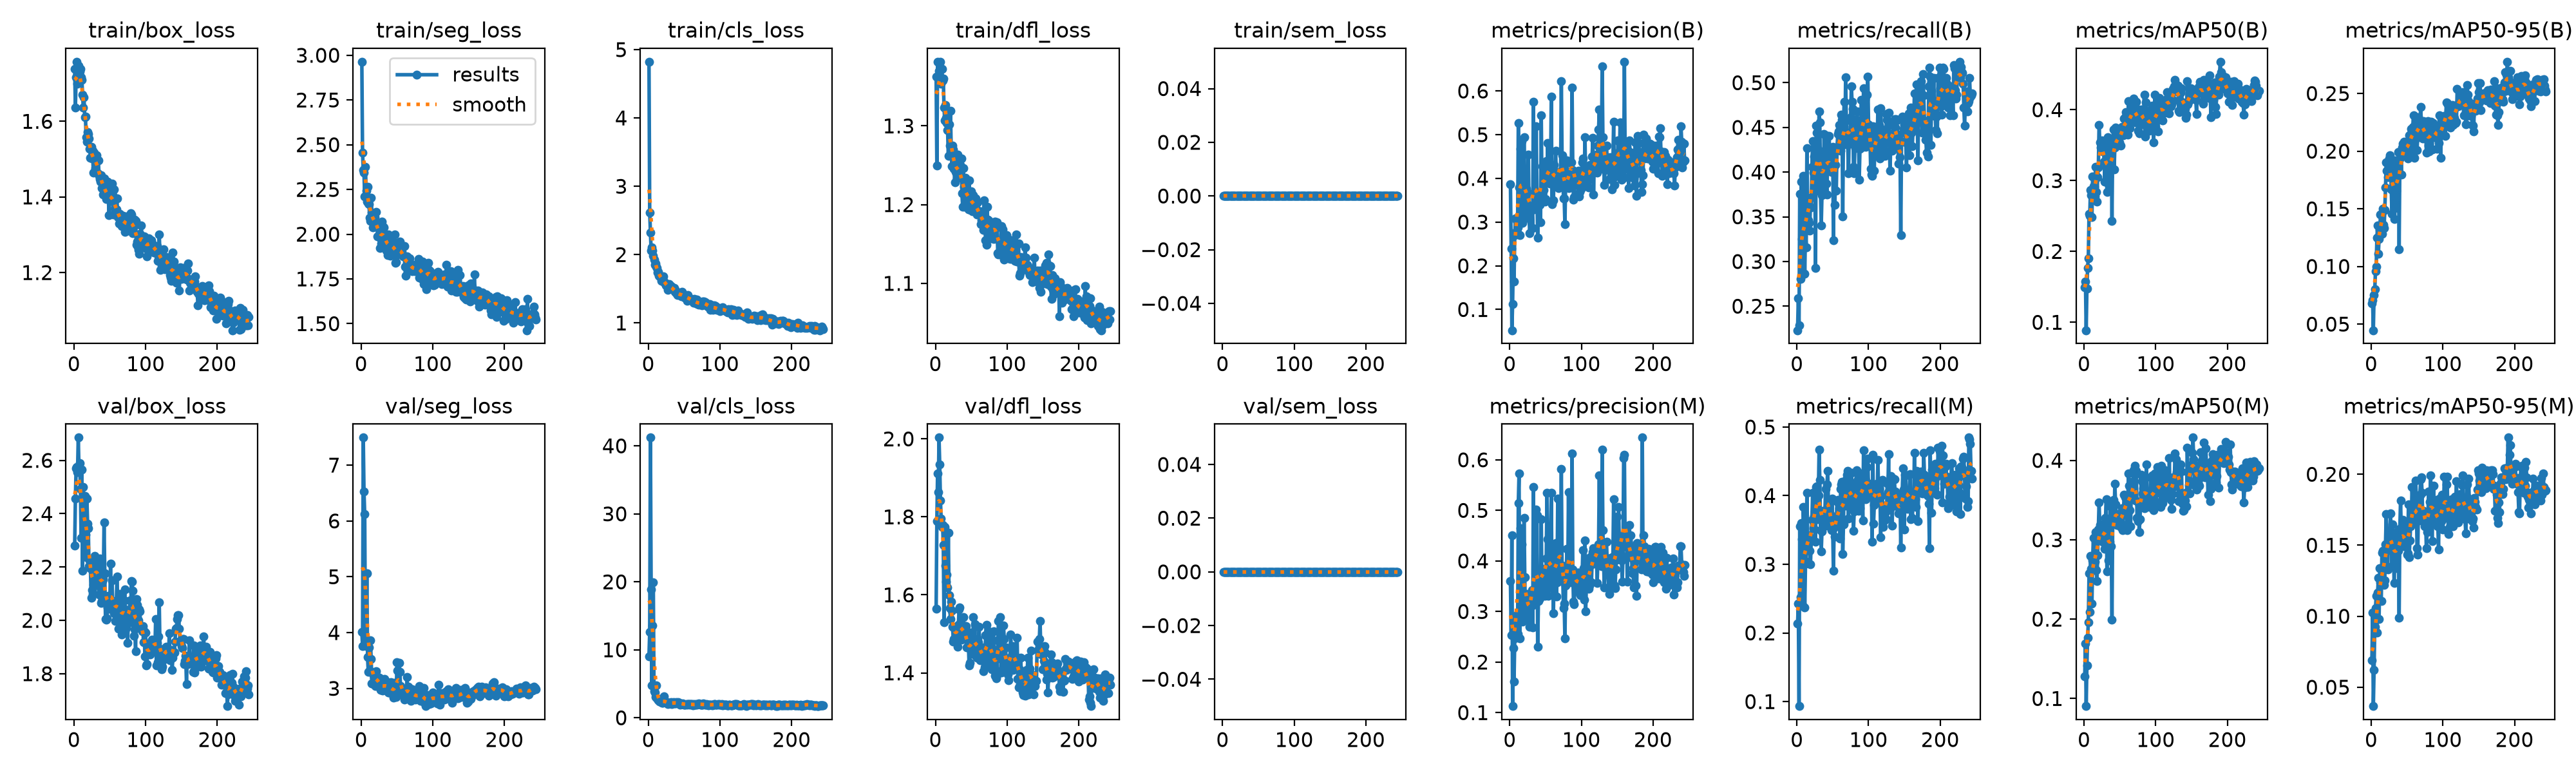

--- confusion_matrix.png ---


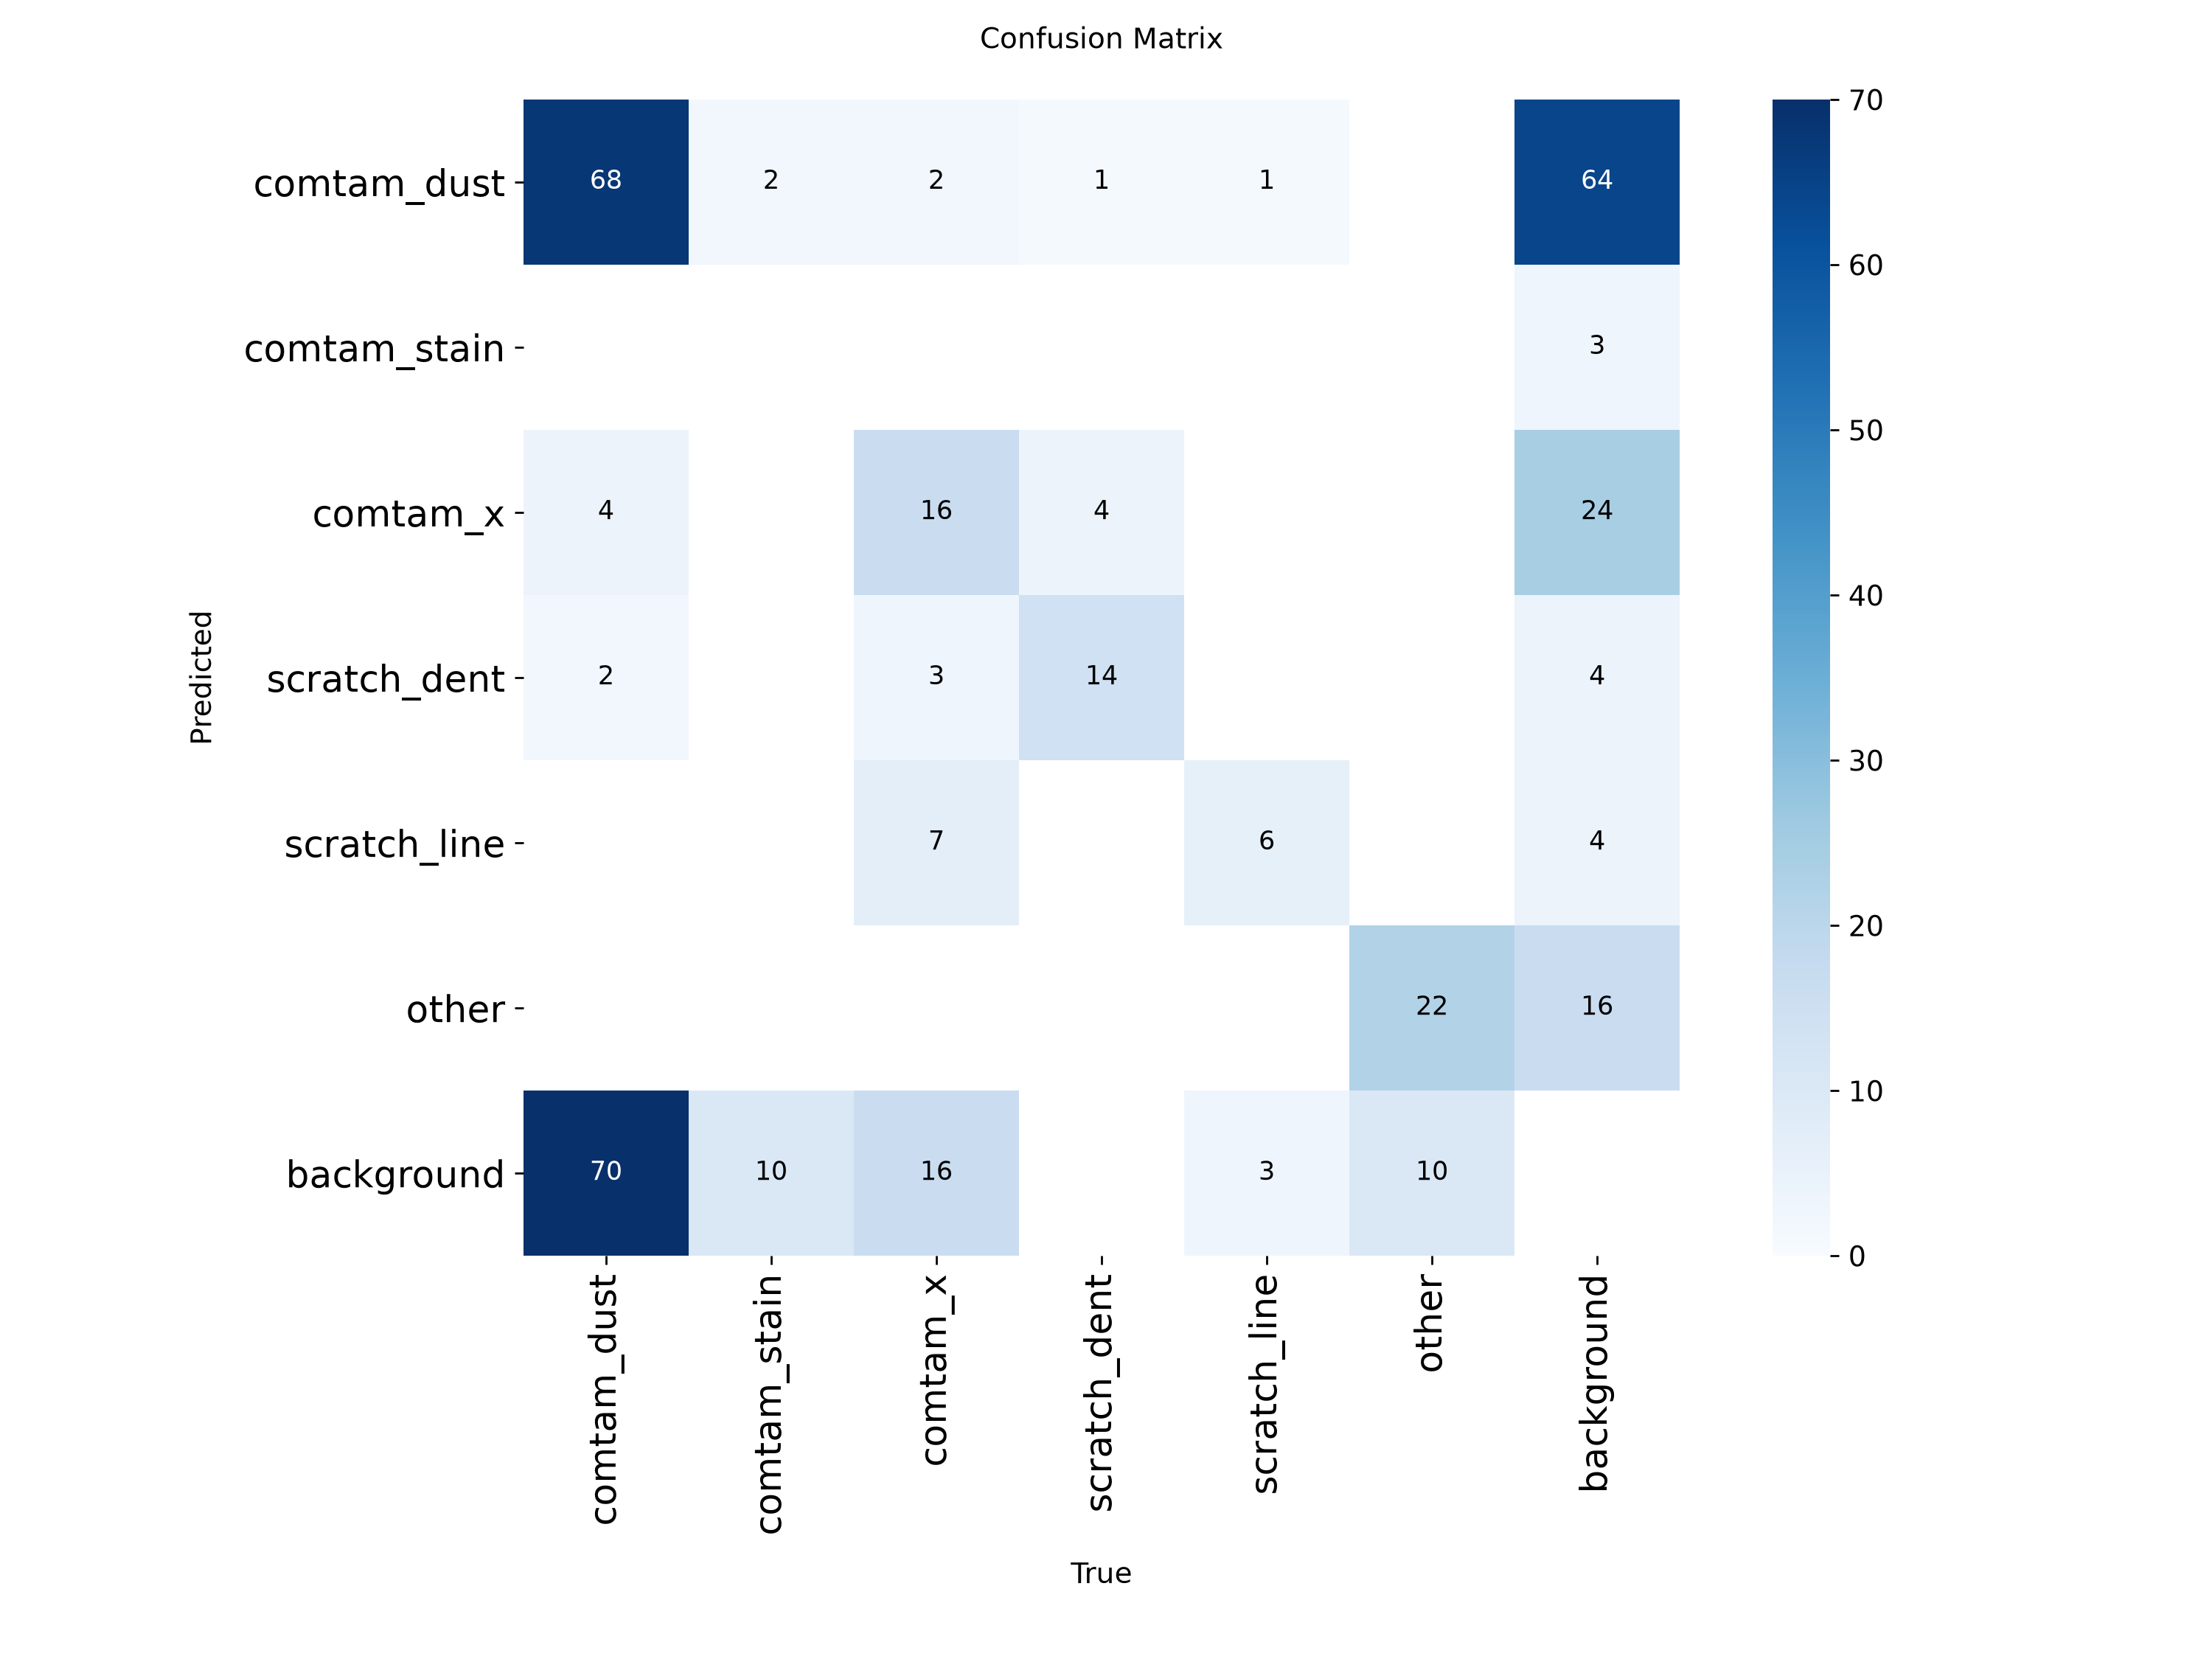

--- val_batch0_pred.jpg ---


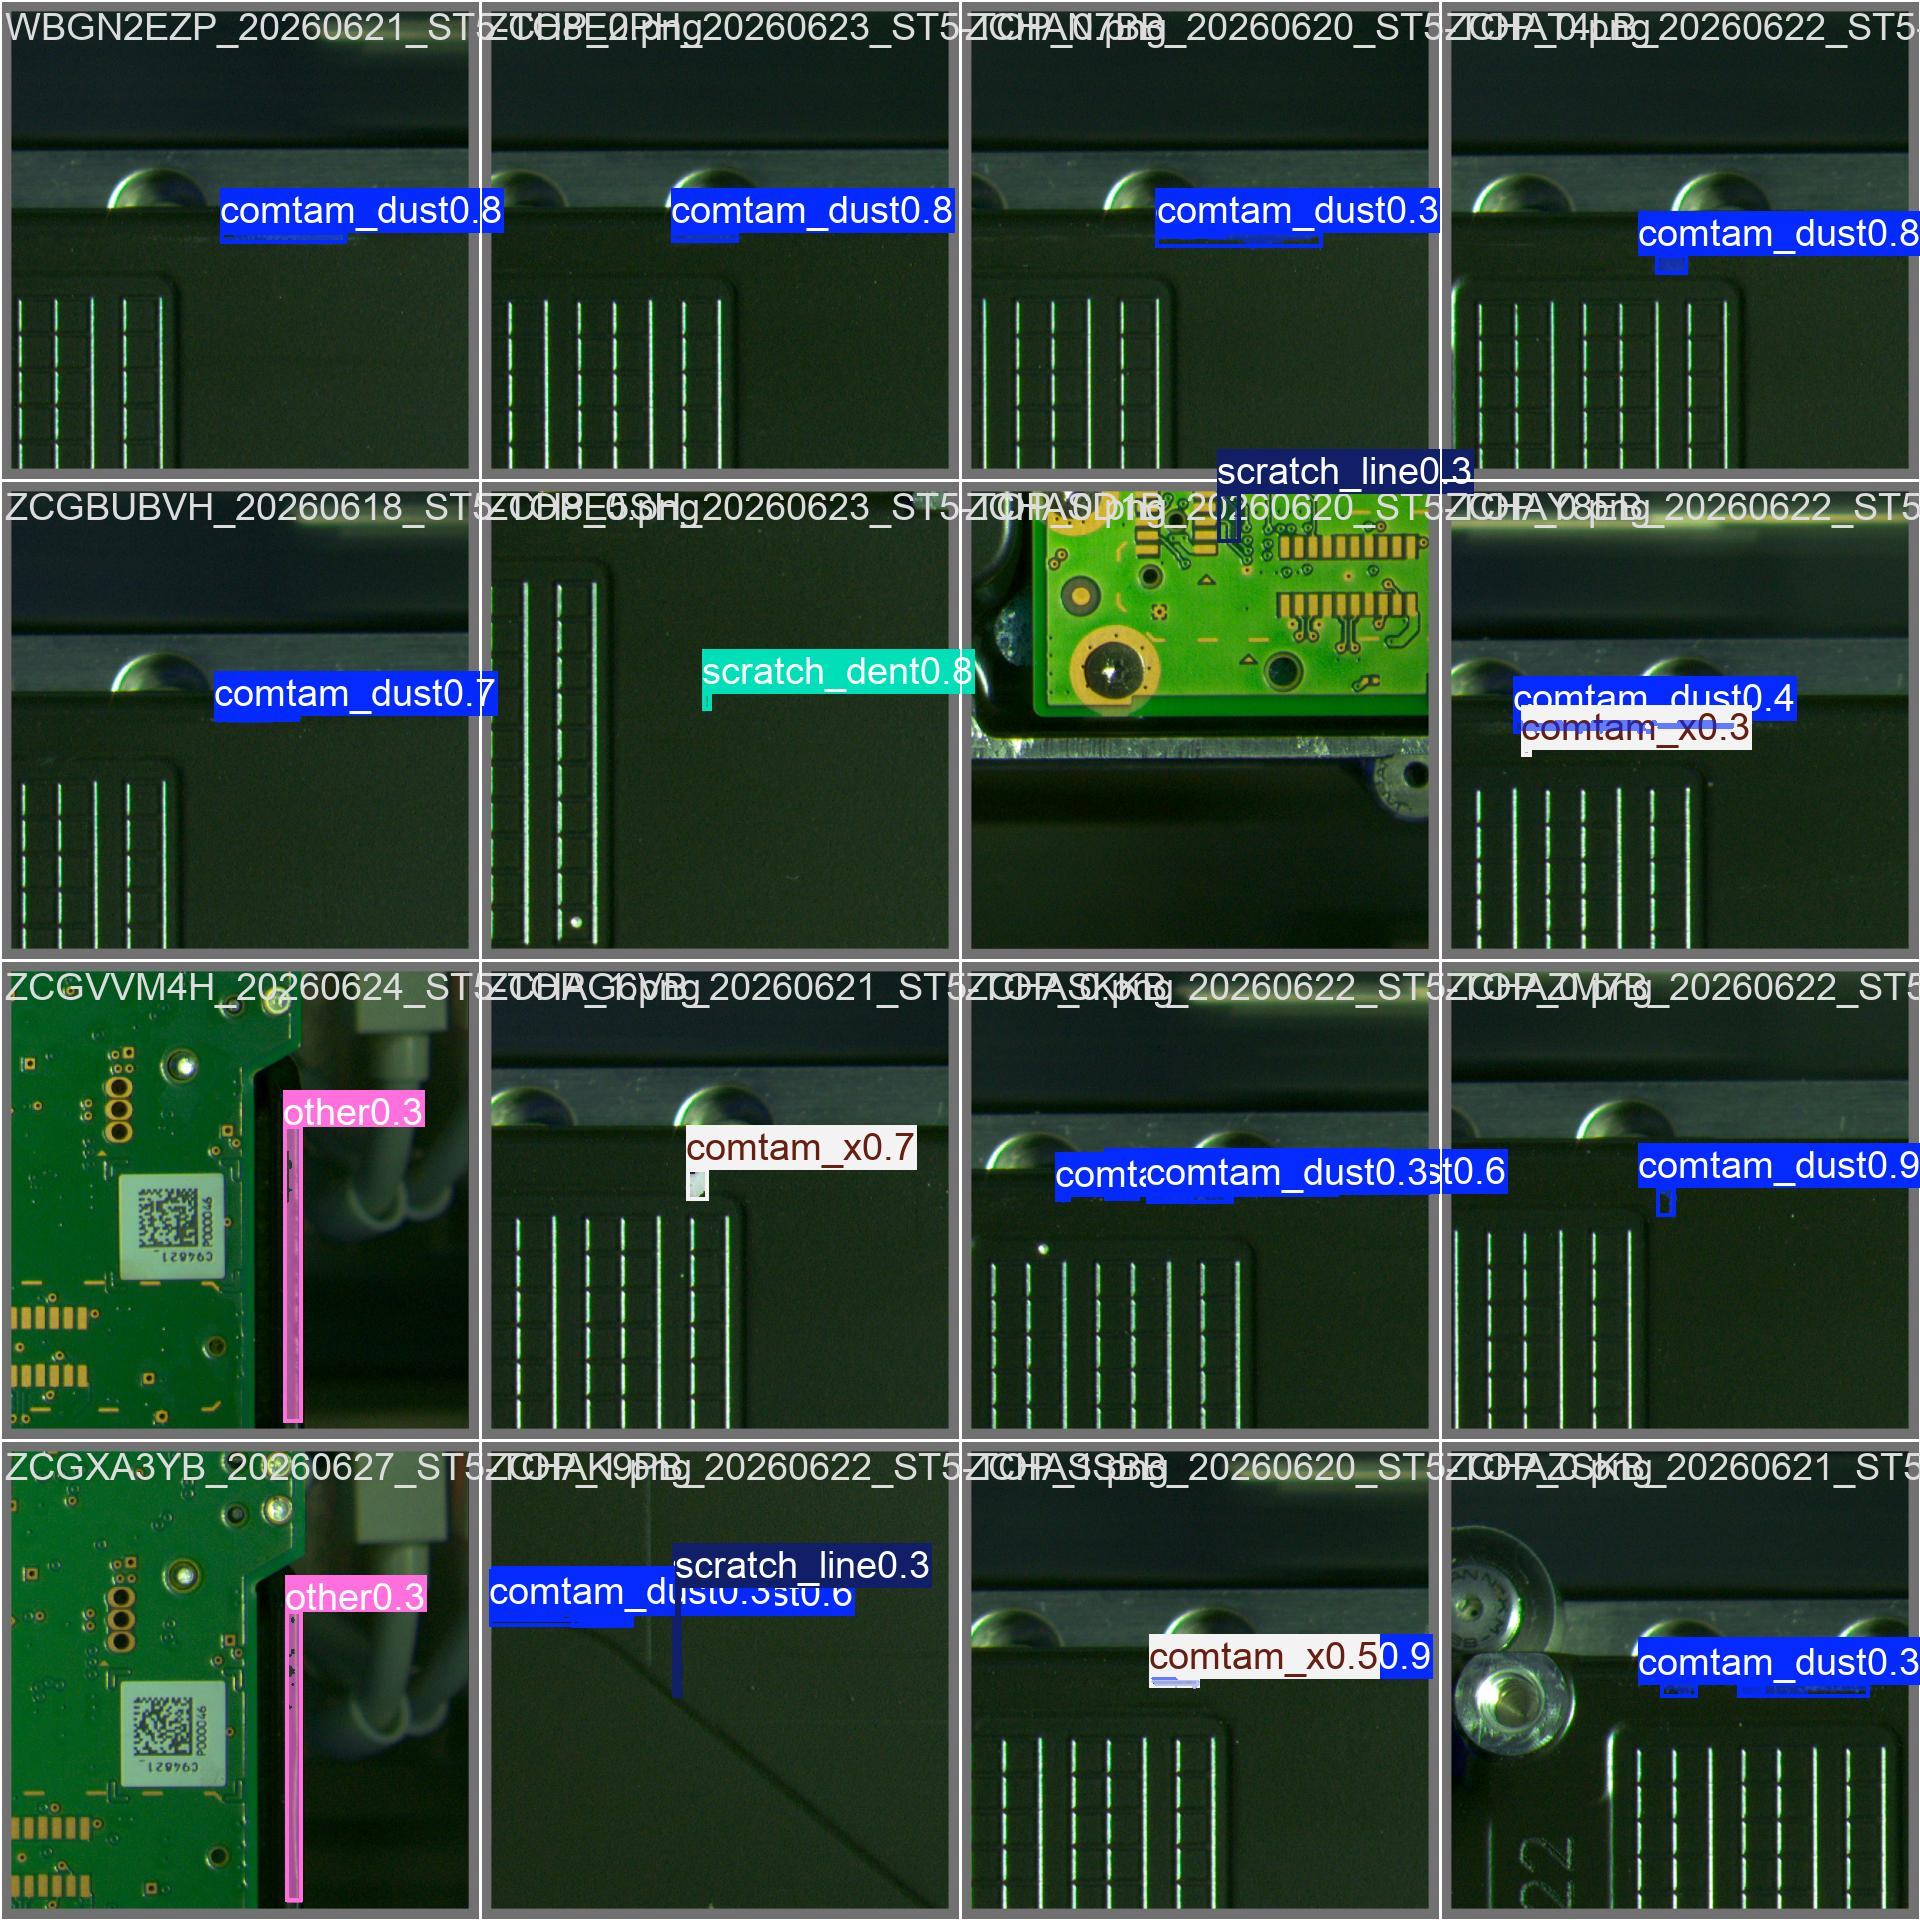

In [ ]:
from IPython.display import Image, display

results_dir = resolve(cfg["training"]["output_dir"]) / "train"

for chart in ["results.png", "confusion_matrix.png", "val_batch0_pred.jpg"]:
    path = results_dir / chart
    if path.exists():
        print(f"--- {chart} ---")
        display(Image(filename=str(path), width=800))
    else:
        print(f"[not found] {path}")

---
## Cell 6b — Final Exam: Evaluate on the Test Split

The **val** split steered training (early stopping picked the "best" epoch using it),  
so its score is a little optimistic — the model was tuned to look good on it.

The **test** split was never touched during training. Scoring on it **once, at the end**  
gives the honest number you should report. If test is much worse than val, the model  
memorized quirks of the val set instead of truly learning the defects.

In [ ]:
from ultralytics import YOLO

out_dir   = resolve(cfg["training"]["output_dir"])
best_ckpt = out_dir / "train" / "weights" / "best.pt"

if not best_ckpt.exists():
    print(f"No trained model found at {best_ckpt}")
    print("Run Step 3 (Train) first.")
else:
    model = YOLO(best_ckpt)
    metrics = model.val(
        data=str(yolo_dir / "data.yaml"),
        split="test",
        project=str(out_dir),
        name="test_eval",
        exist_ok=True,
    )
    print(f"\n=== Test-set results (report these numbers) ===")
    print(f"Box  mAP50: {metrics.box.map50:.3f}  |  Box  mAP50-95: {metrics.box.map:.3f}")
    print(f"Mask mAP50: {metrics.seg.map50:.3f}  |  Mask mAP50-95: {metrics.seg.map:.3f}")

---
## Cell 7 — STEP 4: Predict on New Images

### This is the payoff!

Now that the model is trained, you can point it at **brand new photos** it has never seen.

**Confidence score** = how sure the model is (0.0 = no idea, 1.0 = totally certain).  
We filter out anything below 0.25 (25% confidence) — too low = probably a false alarm.


In [ ]:
from ultralytics import YOLO

out_dir    = resolve(cfg["training"]["output_dir"])
best_ckpt  = out_dir / "train" / "weights" / "best.pt"
input_dir  = yolo_dir / "images" / "test"
output_dir = resolve("test_output")

if not best_ckpt.exists():
    print(f"No trained model found at {best_ckpt}")
    print("Run Step 3 (Train) first.")
elif not input_dir.exists():
    print(f"Test split not found: {input_dir}")
    print("Run Step 1 (Prepare Dataset) first.")
else:
    imgs = sorted(input_dir.glob('*.png')) + sorted(input_dir.glob('*.jpg'))
    if not imgs:
        print(f"No images found in {input_dir}")
    else:
        output_dir.mkdir(exist_ok=True)

        print(f"Model  : {best_ckpt}")
        print(f"Input  : {input_dir}  ({len(imgs)} images)")
        print(f"Output : {output_dir}")
        print()

        model = YOLO(best_ckpt)
        model.predict(
            source=str(input_dir),
            save=True,
            project=str(output_dir.parent),
            name=output_dir.name,
            exist_ok=True,
            conf=0.25,
            verbose=True,
        )

        print(f"\nDone! Annotated images saved to: {output_dir}/")

Model  : C:\Thawanrat_Internship-Project\ML_pipeline\models\train\weights\best.pt
Input  : C:\Thawanrat_Internship-Project\ML_pipeline\yolo_data\images\test  (138 images)
Output : C:\Thawanrat_Internship-Project\ML_pipeline\test_output


image 1/138 C:\Thawanrat_Internship-Project\ML_pipeline\yolo_data\images\test\ZCGVVM4H_20260624_ST5-TOP_0.png: 640x640 2 others, 44.7ms
image 2/138 C:\Thawanrat_Internship-Project\ML_pipeline\yolo_data\images\test\ZCHA9ZJB_20260620_ST5-TOP_0.png: 640x640 2 comtam_dusts, 44.9ms
image 3/138 C:\Thawanrat_Internship-Project\ML_pipeline\yolo_data\images\test\ZCHAA2KB_20260620_ST5-TOP_0.png: 640x640 7 comtam_dusts, 1 comtam_x, 35.6ms
image 4/138 C:\Thawanrat_Internship-Project\ML_pipeline\yolo_data\images\test\ZCHABHZB_20260623_ST5-TOP_0.png: 640x640 2 comtam_dusts, 7.3ms
image 5/138 C:\Thawanrat_Internship-Project\ML_pipeline\yolo_data\images\test\ZCHAD6GB_20260622_ST5-TOP_0.png: 640x640 1 comtam_dust, 8.5ms
image 6/138 C:\Thawanrat_Internship-Project\ML_pi

---
## Cell 8 — Show Prediction Results

Displays the annotated output images right here in the notebook — no need to open a folder.  
Each image shows colored polygon masks with class labels and confidence scores.

Showing 3 prediction result(s):

ZCGVVM4H_20260624_ST5-TOP_0.jpg


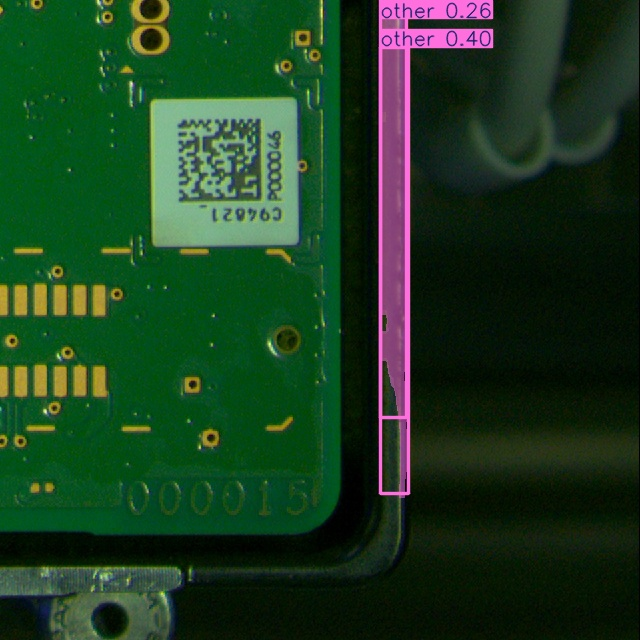


ZCHA9ZJB_20260620_ST5-TOP_0.jpg


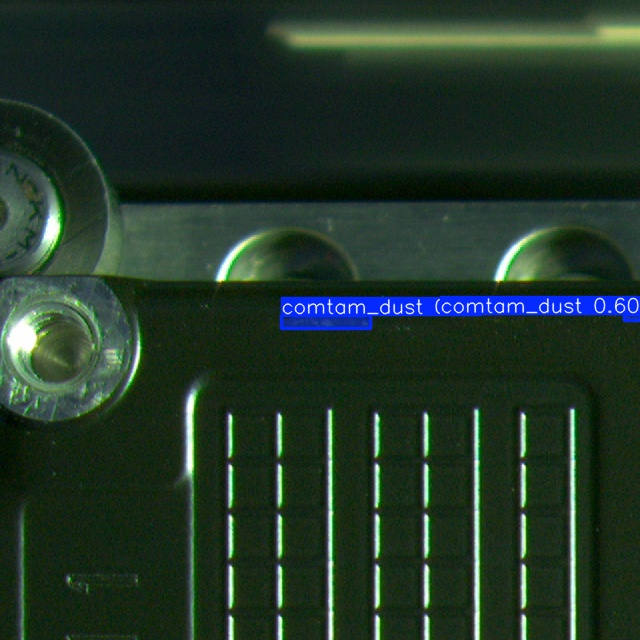


ZCHAA2KB_20260620_ST5-TOP_0.jpg


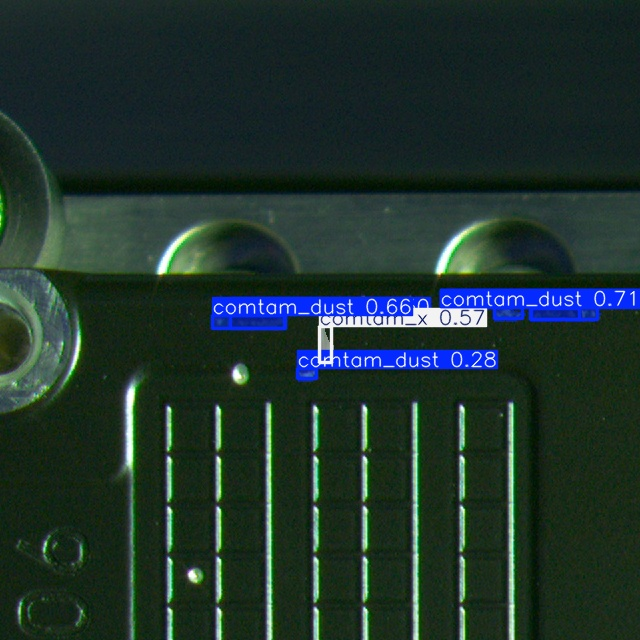

In [ ]:
from IPython.display import Image, display
n = 3
output_dir = resolve("test_output")

result_imgs = sorted(output_dir.glob("*.png")) + sorted(output_dir.glob("*.jpg"))

if not result_imgs:
    print("No output images found. Run Step 4 first.")
else:
    print(f"Showing {n} prediction result(s):")
    for img_path in result_imgs[:3]:
        print(f"\n{img_path.name}")
        display(Image(filename=str(img_path), width=700))

---
## Cell 9 — Side-by-Side Comparison: Original vs Prediction

Shows the original test image next to the predicted (annotated) image, side by side.
Change **`n`** to control how many pairs to display and save.

Saved images land in **`test_side_by_side/`** — one file per pair, same filename as the original.

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

input_dir = yolo_dir / "images" / "test"
pred_dir  = resolve("test_output")
side_dir  = resolve("test_side_by_side")
side_dir.mkdir(exist_ok=True)

orig_imgs = sorted(input_dir.glob("*.png")) + sorted(input_dir.glob("*.jpg"))
pred_map  = {p.stem: p for p in list(pred_dir.glob("*.png")) + list(pred_dir.glob("*.jpg"))}

pairs = [(img, pred_map[img.stem]) for img in orig_imgs if img.stem in pred_map]

if not pairs:
    print("No matching pairs found. Run Step 4 (Predict) first.")
else:
    for i, (orig_path, pred_path) in enumerate(pairs):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        ax1.imshow(Image.open(orig_path).convert("RGB"))
        ax1.set_title("Original", fontsize=13)
        ax1.axis("off")
        ax2.imshow(Image.open(pred_path).convert("RGB"))
        ax2.set_title("Prediction", fontsize=13)
        ax2.axis("off")
        fig.suptitle(orig_path.name, fontsize=11, y=0.02)
        plt.tight_layout()
        fig.savefig(side_dir / orig_path.stem, dpi=150, bbox_inches="tight")
        if i < n:
            plt.show()
        plt.close(fig)
        print(f"Saved: {orig_path.name}")

    print(f"\n{len(pairs)} saved, {min(n, len(pairs))} shown. Folder: {side_dir}/")

<Figure size 1400x600 with 2 Axes>

Saved: ZCGVVM4H_20260624_ST5-TOP_0.png


<Figure size 1400x600 with 2 Axes>

Saved: ZCHA9ZJB_20260620_ST5-TOP_0.png


<Figure size 1400x600 with 2 Axes>

Saved: ZCHAA2KB_20260620_ST5-TOP_0.png
Saved: ZCHABHZB_20260623_ST5-TOP_0.png
Saved: ZCHAD6GB_20260622_ST5-TOP_0.png
Saved: ZCHAEE0B_20260620_ST5-TOP_0.png
Saved: ZCHAERJB_20260623_ST5-TOP_0.png
Saved: ZCHAK8KB_20260623_ST5-TOP_0.png
Saved: ZCHASD1B_20260620_ST5-TOP_2.png
Saved: ZCHASSJB_20260622_ST5-TOP_0.png
Saved: ZCHAT4LB_20260622_ST5-TOP_1.png
Saved: ZCHAW5BB_20260620_ST5-TOP_0.png
Saved: ZCHAWL4B_20260621_ST5-TOP_0.png
Saved: ZCHAZGYB_20260621_ST5-TOP_0.png
Saved: ZCHAZS0B_20260622_ST5-TOP_0.png
Saved: ZCHAZSKB_20260621_ST5-TOP_0.png
Saved: ZCHAZSVB_20260621_ST5-TOP_1.png
Saved: ZCHB002B_20260626_ST5-TOP_0.png
Saved: ZCHB002B_20260626_ST5-TOP_1.png
Saved: ZCHB0DLB_20260621_ST5-TOP_0.png
Saved: ZCHB0WWB_20260620_ST5-TOP_0.png
Saved: ZCHB461B_20260620_ST5-TOP_1.png
Saved: ZCHB4LKB_20260620_ST5-TOP_0.png
Saved: ZCHB7L3B_20260621_ST5-TOP_0.png
Saved: ZCHB7SNB_20260621_ST5-TOP_0.png
Saved: ZCHB7TMB_20260621_ST5-TOP_0.png
Saved: ZCHB827B_20260621_ST5-TOP_0.png
Saved: ZCHBAP2B_20260622_

---
## Cell 10 — Predict on a Different Folder (Optional)

How it works:
1. Drop your unseen images into **`test_result/`**
2. Run this cell
3. Check **`test_result_output/`** — each image will have colored polygon masks drawn over any defects, with the class name and confidence score printed next to each one


In [ ]:
MY_FOLDER = "test_result"   # <-- change this to any folder you want

from ultralytics import YOLO

out_dir    = resolve(cfg["training"]["output_dir"])
best_ckpt  = out_dir / "train" / "weights" / "best.pt"
input_dir  = resolve(MY_FOLDER)
output_dir = resolve(MY_FOLDER + "_output")

if not best_ckpt.exists():
    print(f"No trained model found at {best_ckpt}")
    print("Run Step 3 (Train) first.")
elif not input_dir.exists():
    print(f"Input folder not found: {input_dir}")
    print("Create the folder and add some .png or .jpg images to it.")
else:
    imgs = sorted(input_dir.glob('*.png')) + sorted(input_dir.glob('*.jpg'))
    if not imgs:
        print(f"No images found in {input_dir}")
    else:
        output_dir.mkdir(exist_ok=True)

        print(f"Model  : {best_ckpt}")
        print(f"Input  : {input_dir}  ({len(imgs)} images)")
        print(f"Output : {output_dir}")
        print()

        model = YOLO(best_ckpt)
        model.predict(
            source=str(input_dir),
            save=True,
            project=str(output_dir.parent),
            name=output_dir.name,
            exist_ok=True,
            conf=0.25,
            verbose=True,
        )

        print(f"\nDone! Annotated images saved to: {output_dir}/")

Model  : C:\Thawanrat_Internship-Project\ML_pipeline\models\train\weights\best.pt
Input  : C:\Thawanrat_Internship-Project\ML_pipeline\test_result  (235 images)
Output : C:\Thawanrat_Internship-Project\ML_pipeline\test_result_output


image 1/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCH23KVB_20260625_ST5-TOP_0.png: 640x640 1 comtam_dust, 54.9ms
image 2/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHAA26B_20260625_ST5-TOP_0.png: 640x640 2 comtam_dusts, 7.3ms
image 3/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEB6B_20260625_ST5-TOP_0.png: 640x640 2 others, 7.2ms
image 4/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEBRB_20260625_ST5-TOP_0.png: 640x640 1 other, 8.5ms
image 5/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEBXB_20260625_ST5-TOP_0.png: 640x640 1 other, 7.1ms
image 6/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEBZB_20260625_ST5-TOP_0.png: 640x640 2 others, 7.4ms
image